In [41]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

plt.rcParams["figure.figsize"] = (12, 6)

In [42]:
# load processed crypto dataset 
crypto_df = pd.read_csv("../Data/processed/crypto_prices_processed.csv")
crypto_df["Date"] = pd.to_datetime(crypto_df["Date"])

crypto_df.head()

,Date,coin,Open,High,Low,Close,Volume,daily_return,cumulative_return
0,2020-01-01,ADA,0.032832,0.033813,0.032704,0.033458,22948374,NaN,NaN
1,2020-01-02,ADA,0.033474,0.033507,0.032448,0.032751,20843934,-0.021131,-0.021131
2,2020-01-03,ADA,0.032748,0.034427,0.032491,0.034180,30162644,0.043632,0.021579
3,2020-01-04,ADA,0.034191,0.034685,0.033872,0.034595,29535781,0.012142,0.033983
4,2020-01-05,ADA,0.034574,0.035356,0.034545,0.034721,21479178,0.003642,0.037749


In [43]:
# add time column for time-based analysis
crypto_df["year"] = crypto_df["Date"].dt.year
crypto_df["month"] = crypto_df["Date"].dt.to_period("M").astype(str)
crypto_df["quarter"] = crypto_df["Date"].dt.to_period("Q").astype(str)

In [44]:
crypto_df[["Date", "coin", "year", "month", "quarter"]].head()

,Date,coin,year,month,quarter
0,2020-01-01,ADA,2020,2020-01,2020Q1
1,2020-01-02,ADA,2020,2020-01,2020Q1
2,2020-01-03,ADA,2020,2020-01,2020Q1
3,2020-01-04,ADA,2020,2020-01,2020Q1
4,2020-01-05,ADA,2020,2020-01,2020Q1


## Returns over time

In [45]:
# return overtime for each coin annually
annual_returns = (
    crypto_df.groupby(["coin", "year"])["daily_return"]
    .apply(lambda x: (1 + x.dropna()).prod() - 1)
    .reset_index(name="annual_return")
)

annual_returns.head()

,coin,year,annual_return
0,ADA,2020,4.421634
1,ADA,2021,6.222881
2,ADA,2022,-0.811888
3,ADA,2023,1.410901
4,ADA,2024,0.419990


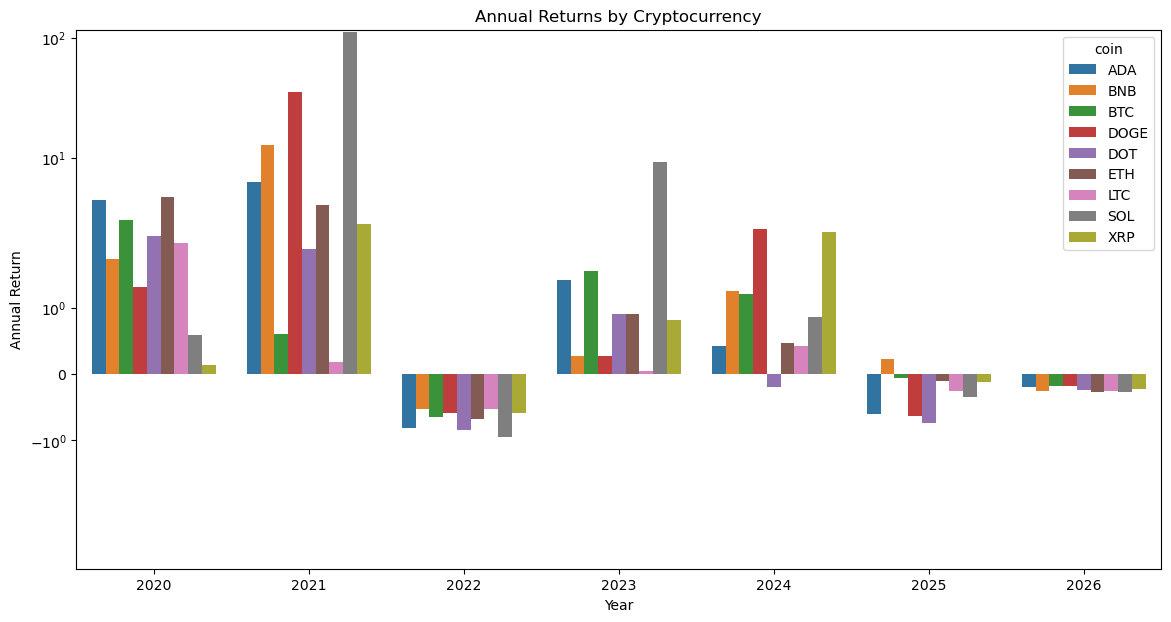

In [46]:
# plot annual returns by coin
plt.figure(figsize=(14, 7))
sns.barplot(data=annual_returns, x="year", y="annual_return", hue="coin")
plt.title("Annual Returns by Cryptocurrency")
plt.ylabel("Annual Return")
plt.xlabel("Year")
plt.xticks(rotation=0)
plt.yscale("symlog")
plt.show()

### Annual returns insight
Annual returns show that cryptocurrency performance is highly regime-dependent. Some assets, especially SOL and DOGE, delivered extraordinary gains in specific periods, but these results were not consistent across all years. This suggests that timing plays a major role in crypto investing, and long-term average performance may hide substantial year-to-year instability.

In [47]:
# returns for each coin by month
monthly_returns = (
    crypto_df.groupby(["coin", "month"])["daily_return"]
    .apply(lambda x: (1 + x.dropna()).prod() - 1)
    .reset_index(name="monthly_return")
)

monthly_returns.head()

,coin,month,monthly_return
0,ADA,2020-01,0.607777
1,ADA,2020-02,-0.116223
2,ADA,2020-03,-0.357334
3,ADA,2020-04,0.566000
4,ADA,2020-05,0.553986


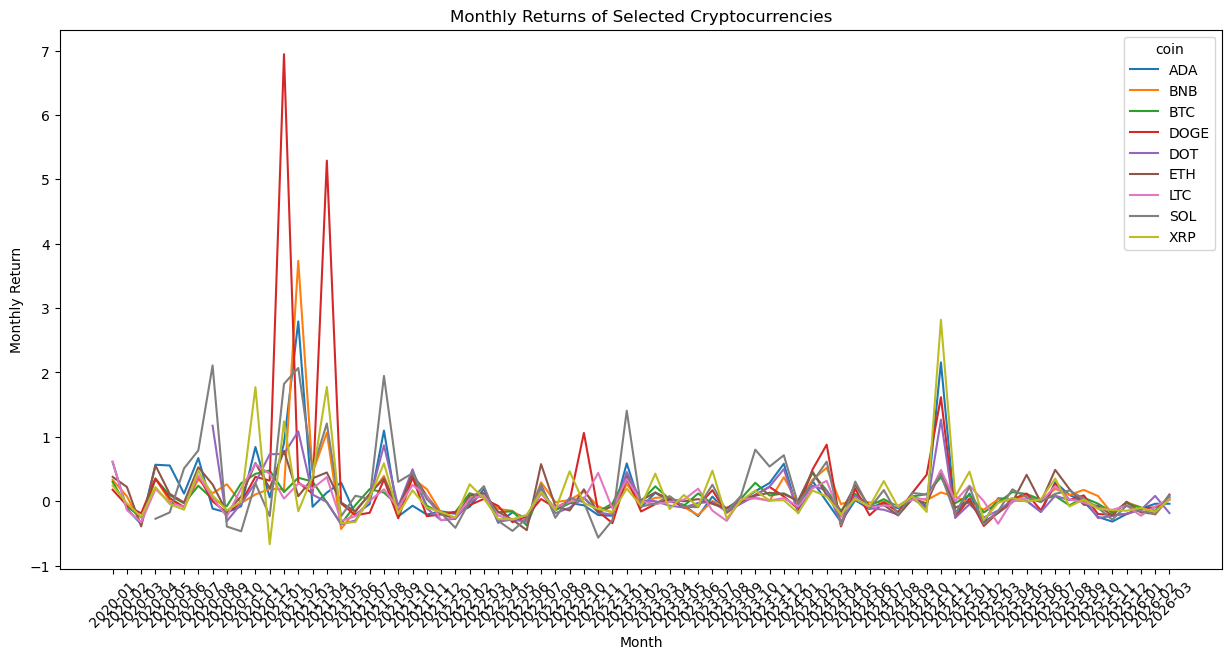

In [48]:
# plot monthly returns by coin
selected_coins = ["ADA","BTC", "ETH", "SOL", "BNB", "DOGE", "DOT", "LTC", "XRP"]
monthly_returns_filtered = monthly_returns[monthly_returns["coin"].isin(selected_coins)]

plt.figure(figsize=(15, 7))
sns.lineplot(data=monthly_returns_filtered, x="month", y="monthly_return", hue="coin")
plt.title("Monthly Returns of Selected Cryptocurrencies")
plt.ylabel("Monthly Return")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.show()

### Monthly return distribution insight
The monthly return distributions reveal large differences in risk across assets. Coins such as DOGE and SOL display wider distributions and more extreme positive outliers, which means they may offer strong upside but also far less predictable short and medium-term behavior. In contrast, BTC and ETH show relatively tighter distributions, suggesting more stable monthly performance.

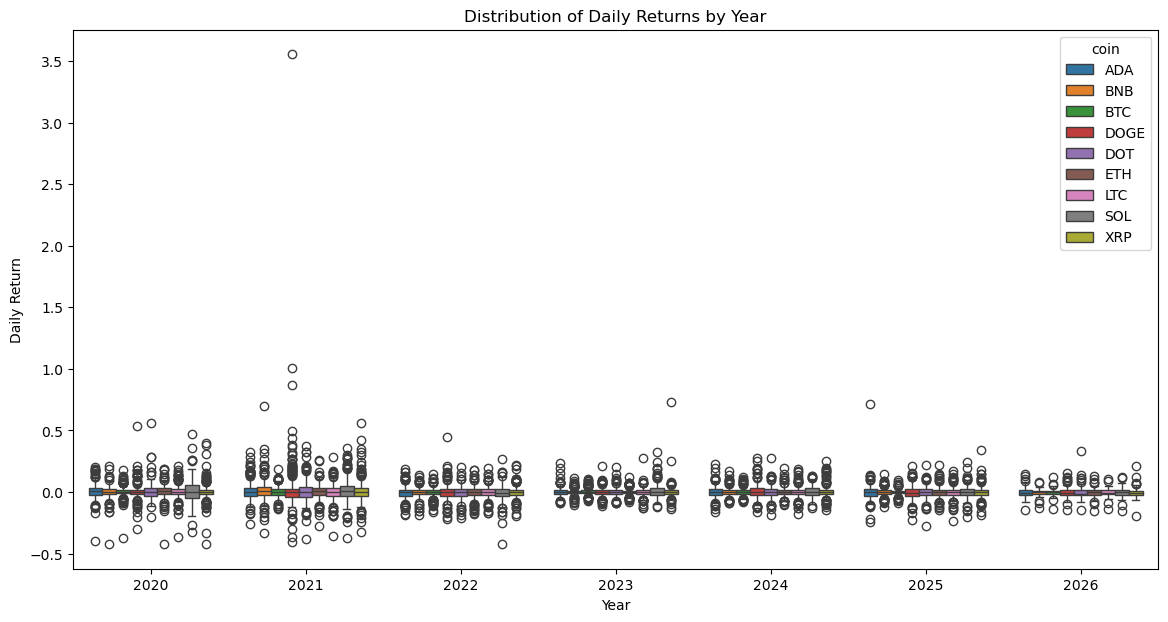

In [49]:
# boxplot daily returns by year
plt.figure(figsize=(14, 7))
sns.boxplot(data=crypto_df[crypto_df["coin"].isin(selected_coins)], x="year", y="daily_return", hue="coin")
plt.title("Distribution of Daily Returns by Year")
plt.ylabel("Daily Return")
plt.xlabel("Year")
plt.show()

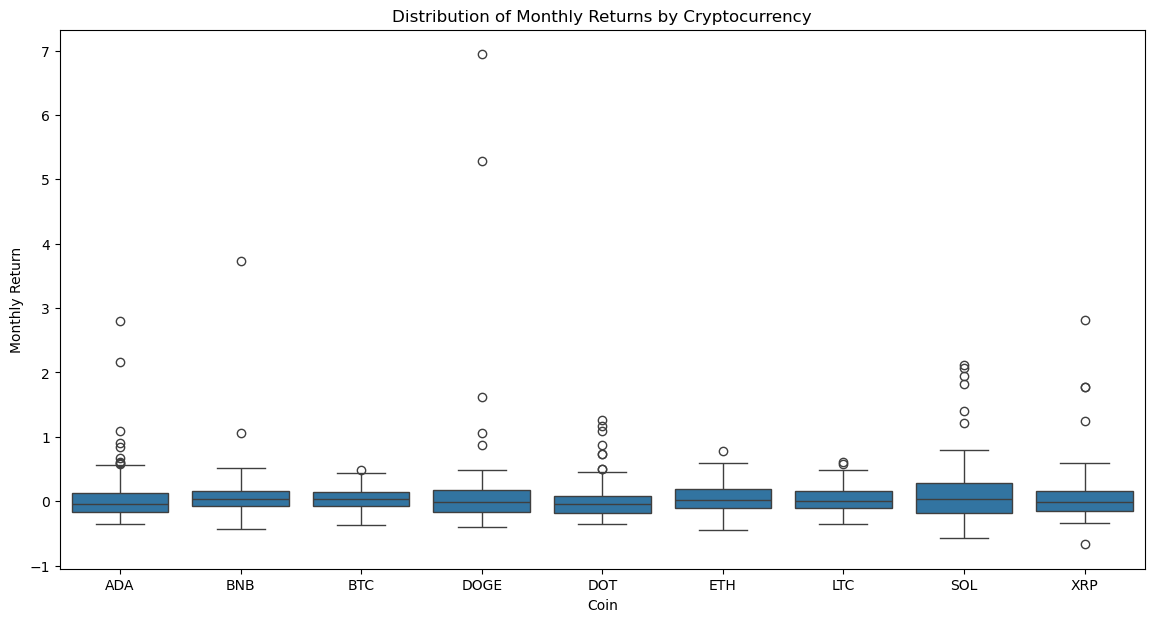

In [50]:
# boxplot monthly returns by coin
plt.figure(figsize=(14, 7))
sns.boxplot(data=monthly_returns_filtered, x="coin", y="monthly_return")
plt.title("Distribution of Monthly Returns by Cryptocurrency")
plt.ylabel("Monthly Return")
plt.xlabel("Coin")
plt.show()

## Rolling returns & rolling volatility

In [51]:
# 30-day rolling returns
crypto_df = crypto_df.sort_values(["coin", "Date"]).reset_index(drop=True)

crypto_df["rolling_return_30d"] = (
    crypto_df.groupby("coin")["daily_return"]
    .transform(lambda x: (1 + x).rolling(30).apply(np.prod, raw=True) - 1)
)

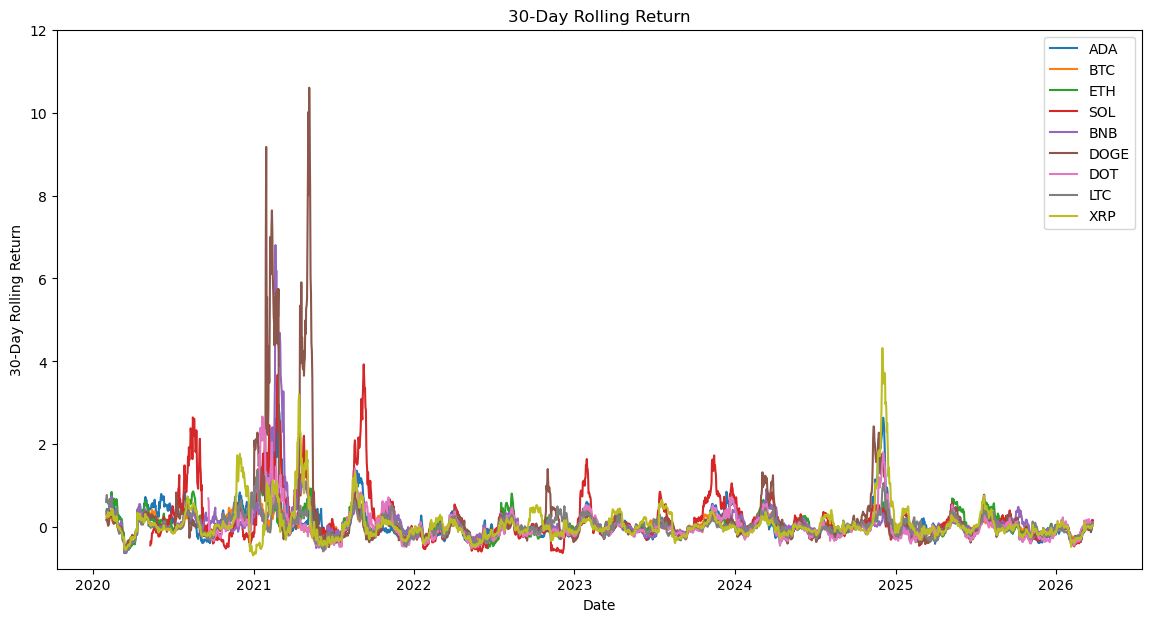

In [52]:
# plot 30-day rolling return
plt.figure(figsize=(14, 7))
for coin in selected_coins:
    subset = crypto_df[crypto_df["coin"] == coin]
    plt.plot(subset["Date"], subset["rolling_return_30d"], label=coin)
plt.title("30-Day Rolling Return")
plt.ylabel("30-Day Rolling Return")
plt.xlabel("Date")
plt.ylim(-1,12)
plt.legend()
plt.show()

### 30-day rolling return insight
The 30-day rolling return chart highlights how quickly momentum can change in crypto markets. Several assets show brief periods of strong positive performance followed by sharp reversals, which suggests that short-term entry and exit timing can materially affect outcomes. This makes a purely passive long-term interpretation incomplete, especially for highly volatile assets

In [53]:
# 90-day rolling returns
crypto_df["rolling_return_90d"] = (
    crypto_df.groupby("coin")["daily_return"]
    .transform(lambda x: (1 + x).rolling(90).apply(np.prod, raw=True) - 1)
)

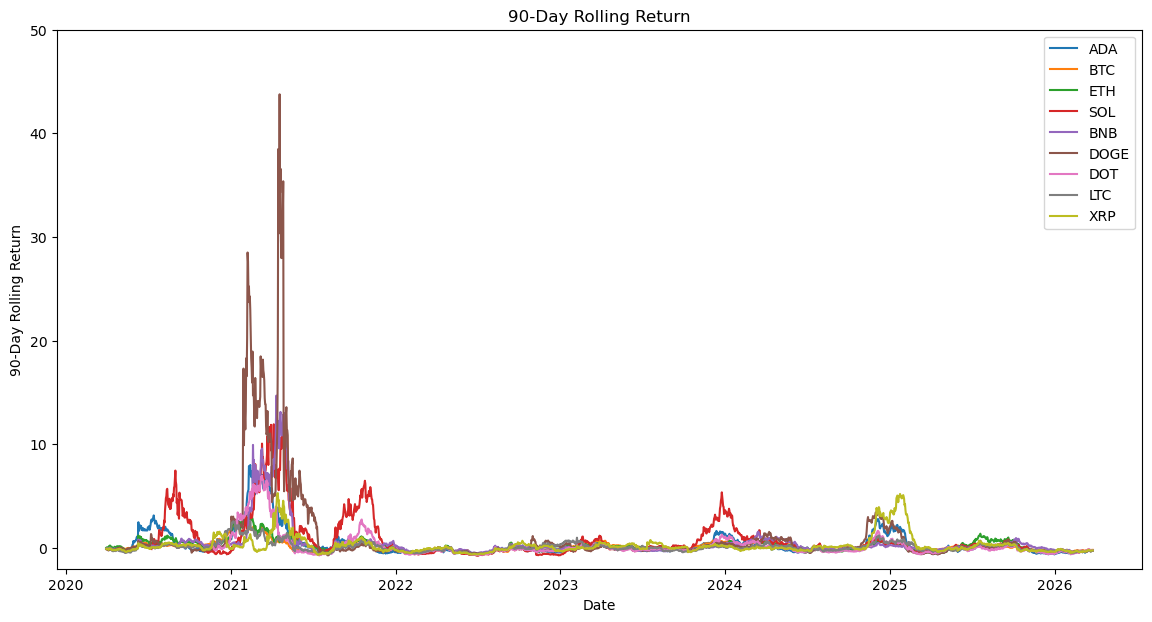

In [54]:
# plot 90-day rolling return
plt.figure(figsize=(14, 7))
for coin in selected_coins:
    subset = crypto_df[crypto_df["coin"] == coin]
    plt.plot(subset["Date"], subset["rolling_return_90d"], label=coin)
plt.title("90-Day Rolling Return")
plt.ylabel("90-Day Rolling Return")
plt.xlabel("Date")
plt.ylim(-2,50)
plt.legend()
plt.show()

### 90-day rolling return insight
The 90-day rolling return view provides a more medium-term perspective and shows that some assets experience sustained performance phases rather than isolated short spikes. However, the size and volatility of those phases differ substantially by coin, reinforcing that holding-period selection matters in crypto portfolio decisions.

In [55]:
# 30-day rolling volatility
crypto_df["rolling_volatility_30d"] = (
    crypto_df.groupby("coin")["daily_return"]
    .transform(lambda x: x.rolling(30).std() * np.sqrt(252))
)

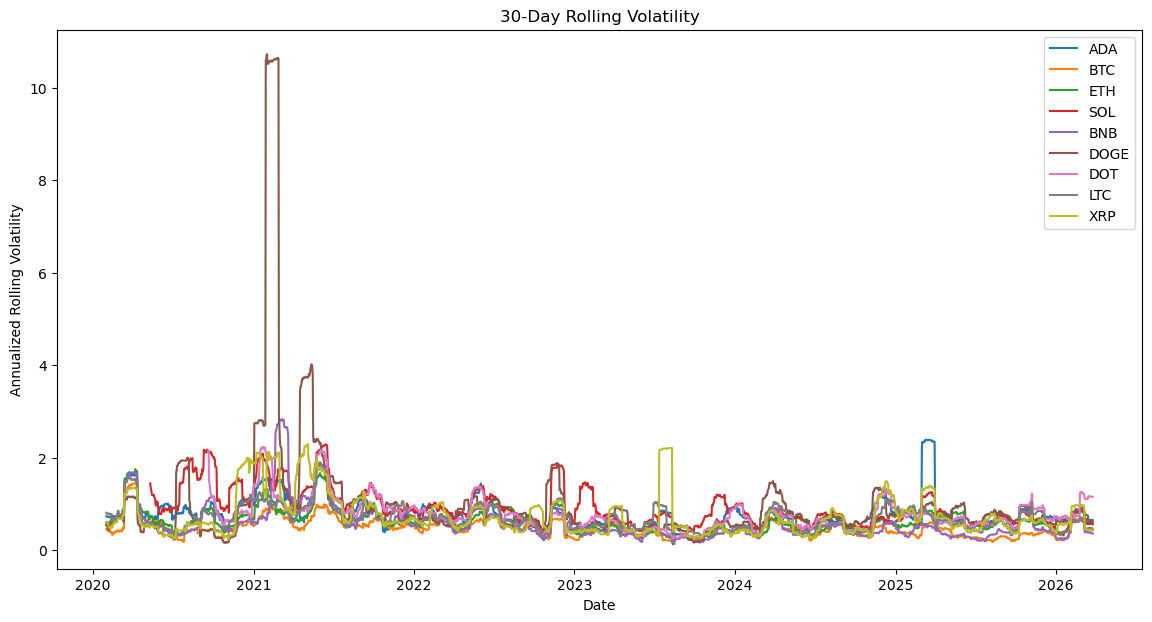

In [56]:
# plot 30-day rolling volatility
plt.figure(figsize=(14, 7))
for coin in selected_coins:
    subset = crypto_df[crypto_df["coin"] == coin]
    plt.plot(subset["Date"], subset["rolling_volatility_30d"], label=coin)
plt.title("30-Day Rolling Volatility")
plt.ylabel("Annualized Rolling Volatility")
plt.xlabel("Date")
plt.legend()
plt.show()

### Rolling volatility insight
Rolling volatility confirms that crypto risk is not constant over time. Volatility clusters around market stress and speculative episodes, particularly for DOGE and SOL, while BTC and ETH tend to remain comparatively more stable. This supports the view that portfolio construction should consider not only returns, but also how risk evolves over time.

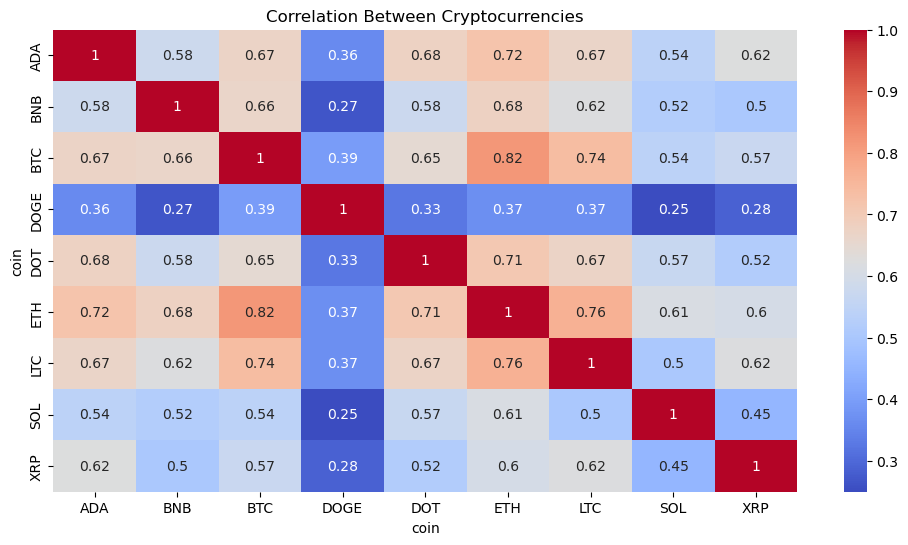

In [69]:
# heatmap of correlations
pivot = crypto_df.pivot(index="Date", columns="coin", values="daily_return")
corr_matrix = pivot.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Between Cryptocurrencies")
plt.show()

## S&P 500 comparison

In [71]:
# download S&P 500 data for comparison
sp500 = yf.download(
    "^GSPC",
    start=crypto_df["Date"].min(),
    end=crypto_df["Date"].max(),
    progress=False
).reset_index()

# flatten columns 
if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.get_level_values(0)

# keep only needed columns
sp500 = sp500[["Date", "Close"]].copy()

# normalize dates to remove time component
sp500["Date"] = pd.to_datetime(sp500["Date"]).dt.normalize()

# compute returns
sp500["sp500_return"] = sp500["Close"].pct_change()

sp500.head()

Price,Date,Close,sp500_return
0,2020-01-02,3257.850098,NaN
1,2020-01-03,3234.850098,-0.007060
2,2020-01-06,3246.280029,0.003533
3,2020-01-07,3237.179932,-0.002803
4,2020-01-08,3253.050049,0.004902


In [72]:
# normalize crypto_df dates
crypto_df["Date"] = pd.to_datetime(crypto_df["Date"]).dt.normalize()

In [73]:
# merge S&P 500 returns with crypto returns
crypto_selected = crypto_df[crypto_df["coin"].isin(selected_coins)][["Date", "coin", "daily_return"]].copy()

merged_market = crypto_selected.merge(
    sp500[["Date", "sp500_return"]],
    on="Date",
    how="left"
)

print("Missing S&P returns after merge:", merged_market["sp500_return"].isna().sum())
merged_market.head()

Missing S&P returns after merge: 6312


,Date,coin,daily_return,sp500_return
0,2020-01-01,ADA,NaN,NaN
1,2020-01-02,ADA,-0.021131,NaN
2,2020-01-03,ADA,0.043632,-0.00706
3,2020-01-04,ADA,0.012142,NaN
4,2020-01-05,ADA,0.003642,NaN


In [74]:
print(crypto_selected["Date"].min(), crypto_selected["Date"].max())
print(sp500["Date"].min(), sp500["Date"].max())

print(crypto_selected["Date"].head())
print(sp500["Date"].head())

2020-01-01 00:00:00 2026-03-26 00:00:00
2020-01-02 00:00:00 2026-03-25 00:00:00
0   2020-01-01
1   2020-01-02
2   2020-01-03
3   2020-01-04
4   2020-01-05
Name: Date, dtype: datetime64[ns]
0   2020-01-02
1   2020-01-03
2   2020-01-06
3   2020-01-07
4   2020-01-08
Name: Date, dtype: datetime64[ns]


In [76]:
merged_market = merged_market.dropna(subset=["sp500_return"]).copy()

In [59]:
# static correlation with S&P 500
sp500_corr = (
    merged_market.groupby("coin")[["daily_return", "sp500_return"]]
    .corr()
    .iloc[0::2, -1]
    .reset_index()
    .rename(columns={"sp500_return": "corr_with_sp500"})
)

sp500_corr

,coin,level_1,corr_with_sp500
0,ADA,daily_return,0.359553
1,BNB,daily_return,0.299811
2,BTC,daily_return,0.386067
3,DOGE,daily_return,0.159332
4,DOT,daily_return,0.336899
5,ETH,daily_return,0.402041
6,LTC,daily_return,0.350917
7,SOL,daily_return,0.316122
8,XRP,daily_return,0.277159


In [60]:
sp500_corr = (
    merged_market.groupby("coin")
    .apply(lambda x: x["daily_return"].corr(x["sp500_return"]))
    .reset_index(name="corr_with_sp500")
)

/var/folders/pl/qjnl2n816kd5trwzkx1r4f9r0000gp/T/ipykernel_8292/440491517.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["daily_return"].corr(x["sp500_return"]))


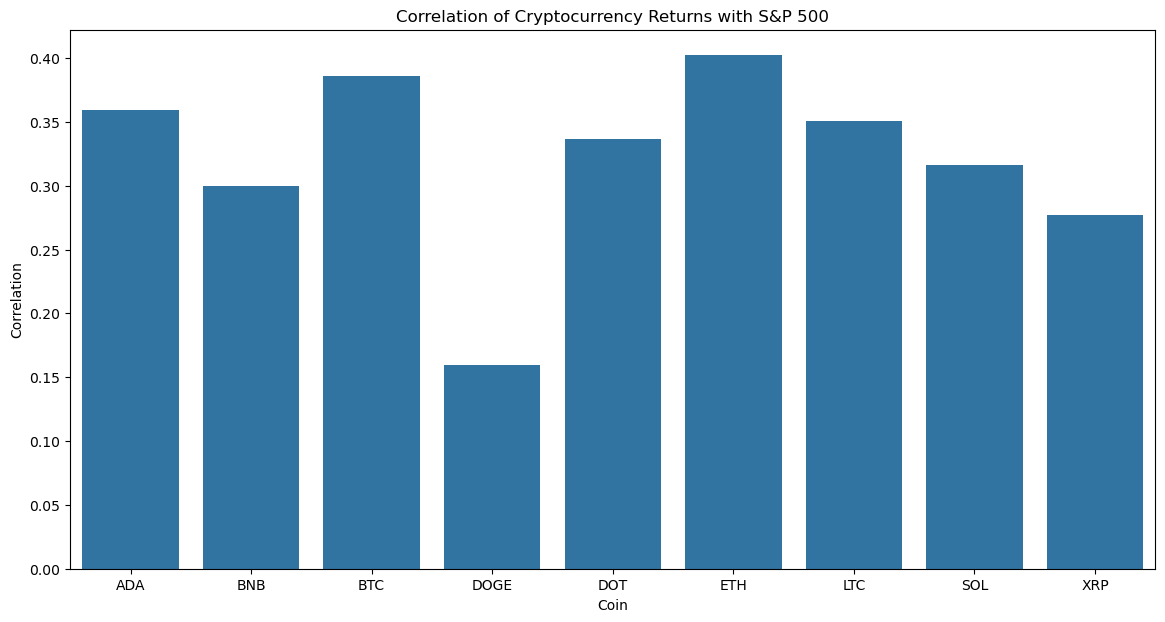

In [61]:
# plot static correlation with S&P 500
plt.figure(figsize=(14, 7))
sns.barplot(data=sp500_corr, x="coin", y="corr_with_sp500")
plt.title("Correlation of Cryptocurrency Returns with S&P 500")
plt.ylabel("Correlation")
plt.xlabel("Coin")
plt.show()

### Correlation with S&P 500 insight
The correlation analysis suggests that cryptocurrencies are not fully independent from traditional markets. Assets such as ETH and BTC show moderate positive correlation with the S&P 500, which indicates that crypto can behave like a broader risk asset during some periods. DOGE, by contrast, appears less correlated, suggesting stronger influence from asset-specific or speculative drivers.

In [77]:
# rolling correlation with S&P 500
merged_market = merged_market.sort_values(["coin", "Date"]).reset_index(drop=True)

def rolling_corr(group):
    return group["daily_return"].rolling(90).corr(group["sp500_return"])

merged_market["rolling_corr_sp500_90d"] = (
    merged_market.groupby("coin", group_keys=False)
    .apply(rolling_corr)
)

/var/folders/pl/qjnl2n816kd5trwzkx1r4f9r0000gp/T/ipykernel_8292/792943125.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(rolling_corr)


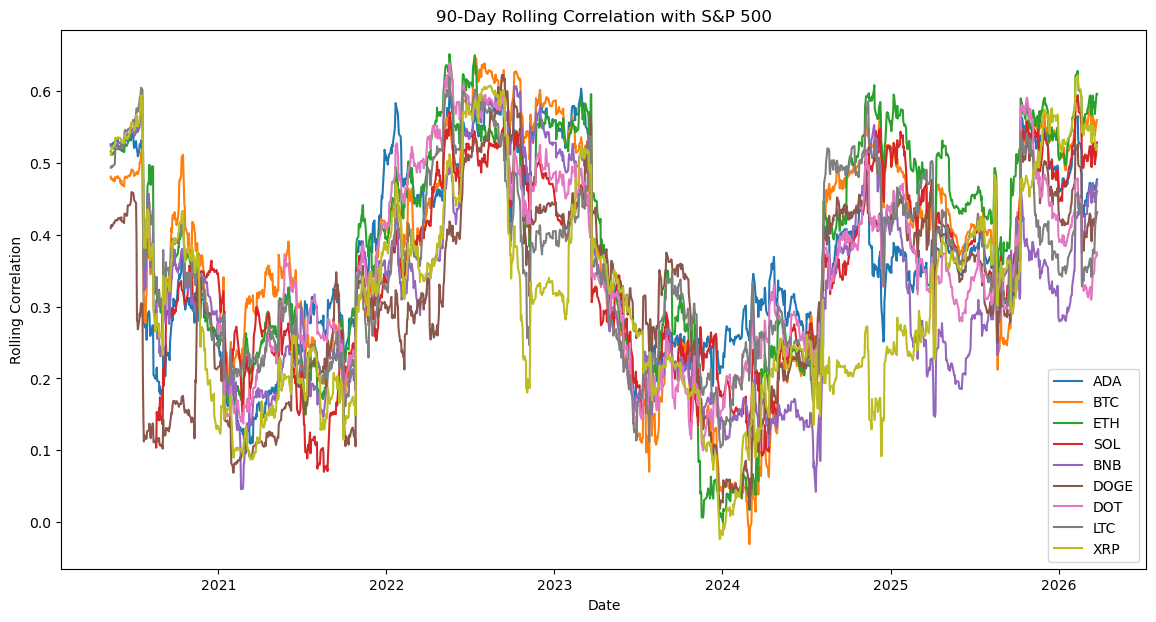

In [78]:
# plot rolling correlation with S&P 500
plt.figure(figsize=(14, 7))

for coin in selected_coins:
    subset = merged_market[merged_market["coin"] == coin]
    plt.plot(subset["Date"], subset["rolling_corr_sp500_90d"], label=coin)

plt.title("90-Day Rolling Correlation with S&P 500")
plt.ylabel("Rolling Correlation")
plt.xlabel("Date")
plt.legend()
plt.show()

### Rolling correlation with S&P 500 insight
Rolling correlation shows that the relationship between crypto and the stock market changes over time. In some periods, cryptocurrencies move more independently, while in others they become more aligned with equity market sentiment. This means diversification benefits are dynamic rather than fixed, and correlations should not be treated as stable constants.

## Simple investor oriented analysis

In [66]:
# best and worst months for each coin
best_worst_months = monthly_returns.groupby("coin").agg(
    best_month=("monthly_return", "max"),
    worst_month=("monthly_return", "min"),
    avg_monthly_return=("monthly_return", "mean"),
    med_monthly_return=("monthly_return", "median")
).reset_index()
best_worst_months

,coin,best_month,worst_month,avg_monthly_return,med_monthly_return
0,ADA,2.792597,-0.357334,0.096681,-0.040481
1,BNB,3.733364,-0.432238,0.102300,0.025989
2,BTC,0.477732,-0.377688,0.047279,0.030967
3,DOGE,6.944468,-0.394144,0.199712,-0.020532
4,DOT,1.266494,-0.358771,0.035676,-0.038499
5,ETH,0.782299,-0.450505,0.067177,0.015509
6,LTC,0.615497,-0.351108,0.025608,0.005780
7,SOL,2.108903,-0.567157,0.168309,0.037486
8,XRP,2.817714,-0.669075,0.098472,-0.008437


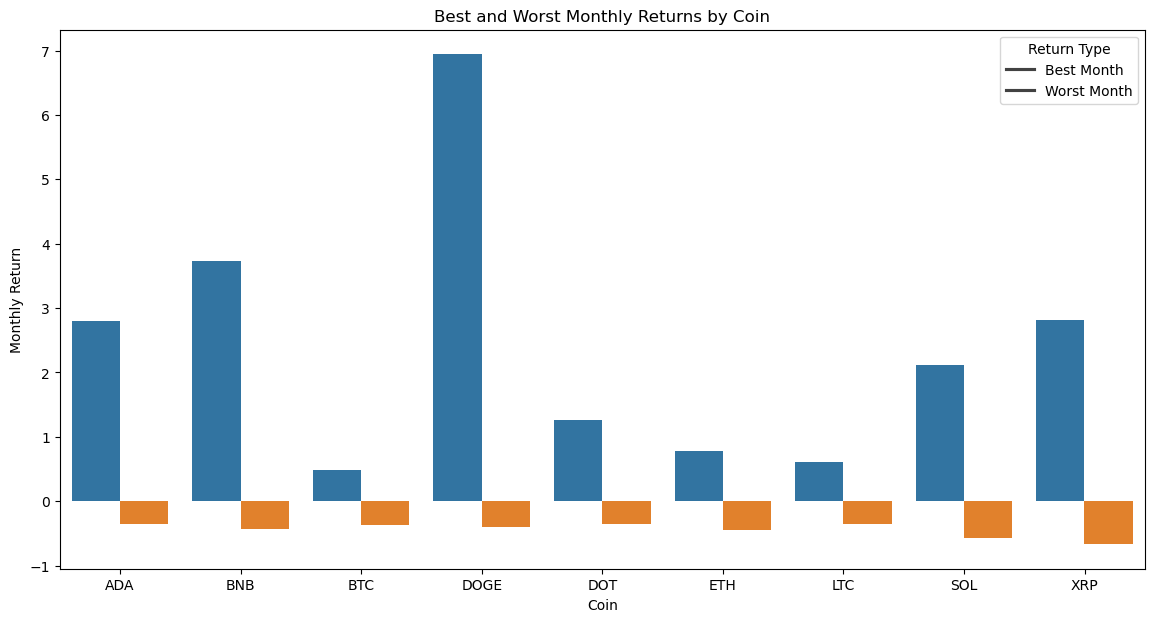

In [ ]:
# plot best and worst months for each coin
plt.figure(figsize=(14, 7))
sns.barplot(data=best_worst_months.melt(id_vars="coin", value_vars=["best_month", "worst_month"]), x="coin", y="value", hue="variable")
plt.title("Best and Worst Monthly Returns by Coin")
plt.ylabel("Monthly Return")
plt.xlabel("Coin")
plt.xticks(rotation=0)
plt.legend(title="Return Type", labels=["Best Month", "Worst Month"])
plt.show()

### Best and worst month insight
The best- and worst-month analysis shows how asymmetric crypto returns can be. Some assets experienced extremely strong months, but these gains were often paired with substantial negative months as well. This reinforces that high-return assets are not necessarily suitable for all investor profiles, especially those with shorter holding horizons or lower risk tolerance.

In [67]:
# best and worst years for each coin
best_worst_years = annual_returns.groupby("coin").agg(
    best_year=("annual_return", "max"),
    worst_year=("annual_return", "min"),
    avg_annual_return=("annual_return", "mean")
).reset_index()
best_worst_years

,coin,best_year,worst_year,avg_annual_return
0,ADA,6.222881,-0.811888,1.552875
1,BNB,12.690814,-0.518575,2.199404
2,BTC,3.027919,-0.642652,0.785455
3,DOGE,35.415209,-0.628441,5.446089
4,DOT,2.204225,-0.838515,0.425767
5,ETH,4.640612,-0.675023,1.277859
6,LTC,1.967565,-0.522258,0.222653
7,SOL,111.713812,-0.941509,17.258606
8,XRP,2.780660,-0.591020,0.739364


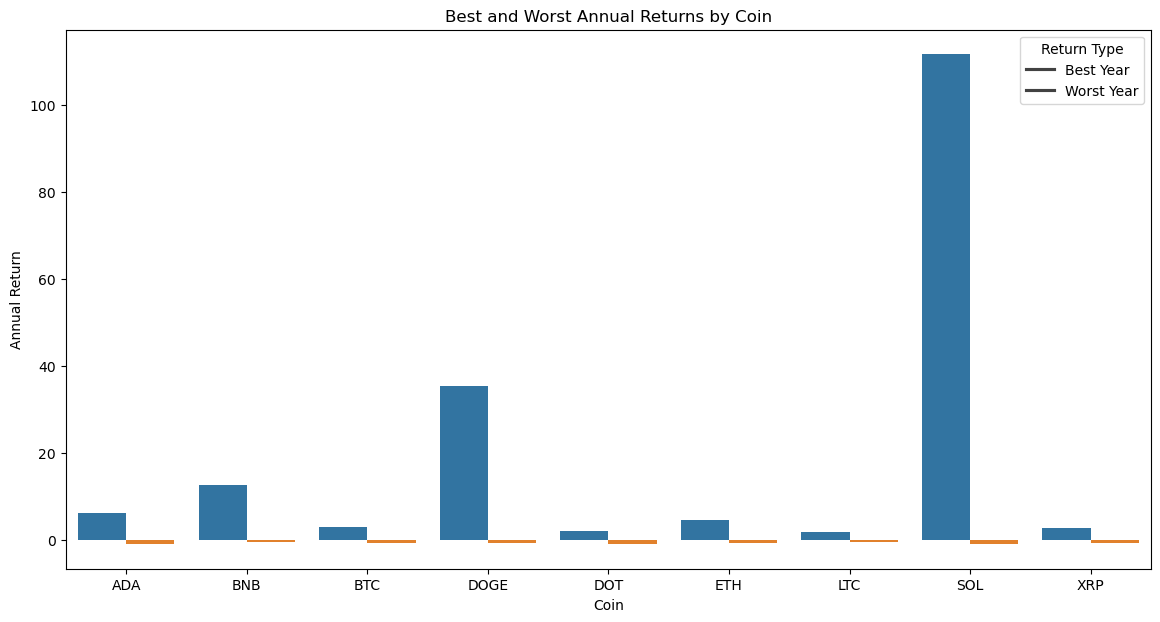

In [80]:
# plot best and worst years for each coin
plt.figure(figsize=(14, 7))
sns.barplot(data=best_worst_years.melt(id_vars="coin", value_vars=["best_year", "worst_year"]), x="coin", y="value", hue="variable")
plt.title("Best and Worst Annual Returns by Coin")
plt.ylabel("Annual Return")
plt.xlabel("Coin")
plt.xticks(rotation=0)
plt.legend(title="Return Type", labels=["Best Year", "Worst Year"])
plt.show()

### Best and worst year insight
The best- and worst-year comparison further highlights the cyclical nature of cryptocurrency markets. Exceptional annual gains can occur, but they are often followed by severe corrections. This supports a more nuanced investment interpretation: performance should be assessed not only by peak outcomes, but also by consistency and downside exposure.

In [68]:
crypto_df.sort_values("daily_return", ascending=False).head(10)

,Date,coin,Open,High,Low,Close,Volume,daily_return,cumulative_return,year,month,quarter,rolling_return_30d,rolling_return_90d,rolling_volatility_30d
7224,2021-01-28,DOGE,0.007481,0.034177,0.007351,0.034084,10971544561,3.555466,15.765370,2021,2021-01,2021Q1,6.597860,12.119322,10.577785
7302,2021-04-16,DOGE,0.181587,0.437700,0.180488,0.365870,69410680685,1.007991,178.965558,2021,2021-04,2021Q2,5.346071,38.489476,3.435189
7198,2021-01-02,DOGE,0.005686,0.013698,0.005584,0.010615,3421562680,0.867194,4.221347,2021,2021-01,2021Q1,2.096558,3.028463,2.732635
19173,2023-07-13,XRP,0.471101,0.887511,0.470103,0.815365,10397344596,0.730750,3.231991,2023,2023-07,2023Q3,0.567750,0.556061,2.151569
1887,2025-03-02,ADA,0.659284,1.134268,0.646119,1.129503,7647921820,0.713276,32.758834,2025,2025-03,2025Q1,0.198756,-0.060139,2.225550
2692,2021-02-19,BNB,195.987854,342.879608,195.385742,332.616028,17982945189,0.697604,23.297904,2021,2021-02,2021Q1,6.806624,9.944452,2.485690
18279,2021-01-30,XRP,0.282152,0.489346,0.279825,0.440244,24417465997,0.560109,1.284999,2021,2021-01,2021Q1,1.002511,0.835903,1.958989
9110,2020-08-22,DOT,2.878570,4.510613,2.816762,4.484690,485801096,0.559877,0.546402,2020,2020-08,2020Q3,NaN,NaN,NaN
7020,2020-07-08,DOGE,0.003097,0.005420,0.003061,0.004750,1226813925,0.537217,1.336448,2020,2020-07,2020Q3,0.838235,1.350322,1.685727
7301,2021-04-15,DOGE,0.121167,0.187326,0.120736,0.182207,17916620386,0.499436,88.624689,2021,2021-04,2021Q2,2.108963,18.447861,2.019629


In [81]:
# export CSVs
annual_returns.to_csv("../Data/processed/annual_returns_by_coin.csv", index=False)
monthly_returns.to_csv("../Data/processed/monthly_returns_by_coin.csv", index=False)
crypto_df.to_csv("../Data/processed/crypto_prices_processed_time_enriched.csv", index=False)
sp500_corr.to_csv("../Data/processed/correlation_with_sp500.csv", index=False)
merged_market.to_csv("../Data/processed/crypto_sp500_merged.csv", index=False)
best_worst_months.to_csv("../Data/processed/best_worst_months.csv", index=False)
best_worst_years.to_csv("../Data/processed/best_worst_years.csv", index=False)